### 1: Imports 

In [24]:
import os
import boto3
import requests
import tarfile
import pickle
import json
import base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sagemaker
from sagemaker import get_execution_role, image_uris
from sagemaker.serializers import IdentitySerializer
from sagemaker.model_monitor import DefaultModelMonitor, DataCaptureConfig, DatasetFormat, CronExpressionGenerator
from datetime import datetime


print("All packages imported successfully!")

All packages imported successfully!


### 2: AWS CONFIGURATION

In [25]:
# Initialize SageMaker session and get AWS configuration
sagemaker_session= sagemaker.Session()

#S3 bucket
bucket= "bicycleandmotorcyclebucket" 

#Region
region= sagemaker_session.boto_region_name

#Role
role= get_execution_role() 

print(f"Bucket: {bucket}")
print(f"AWS Region: {region}")
print(f"Role: {role}")

# Set environment variable for AWS CLI
os.environ["DEFAULT_S3_BUCKET"]= bucket

print ("----------- All Completed Sucessfully!-------------") 

Bucket: bicycleandmotorcyclebucket
AWS Region: us-east-1
Role: arn:aws:iam::039612854101:role/service-role/AmazonSageMaker-ExecutionRole-20250726T234913
----------- All Completed Sucessfully!-------------


### 3: DATA ACQUISITION AND EXTRACTION

In [26]:
def extract_cifar_data(url, filename="cifar.tar.gz"):
    print(f"Downloading CIFAR-100 dataset from {url}...")
    
    # Download the dataset
    r= requests.get(url, stream= True)
    with open(filename, "wb") as file_context:
        file_context.write(r.content) 

    # Extract the archive
    print("Extracting dataset...")
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()

    print("Dataset downloaded and extracted successfully!")



# Download and extract the CIFAR-100 dataset
extract_cifar_data("https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz")
    

Extracting dataset...


/tmp/ipykernel_150/1759198805.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Dataset downloaded and extracted successfully!


### 4: DATA LOADING AND EXPLORATION

In [27]:
print("\n=== Loading and Exploring Data ===") 



with open("./cifar-100-python/meta", "rb") as file: 
    dataset_meta= pickle.load(file, encoding='bytes') 


with open("./cifar-100-python/test", "rb") as file:
    dataset_test= pickle.load(file, encoding='bytes') 


with open("./cifar-100-python/train", "rb") as file:
    dataset_train= pickle.load(file, encoding='bytes') 



print("\nDataset structure:")
print(f"Train keys: {list(dataset_train.keys())}")
print(f"Test keys: {list(dataset_test.keys())}")
print(f"Meta keys: {list(dataset_meta.keys())}")


# Find label numbers for bicycles and motorcycles
bicycle_label = dataset_meta[b'fine_label_names'].index(b'bicycle')
motorcycle_label = dataset_meta[b'fine_label_names'].index(b'motorcycle')

print("\nTarget classes:")
print(f"Bicycle label: {bicycle_label}")
print(f"Motorcycle label: {motorcycle_label}")


=== Loading and Exploring Data ===

Dataset structure:
Train keys: [b'filenames', b'batch_label', b'fine_labels', b'coarse_labels', b'data']
Test keys: [b'filenames', b'batch_label', b'fine_labels', b'coarse_labels', b'data']
Meta keys: [b'fine_label_names', b'coarse_label_names']

Target classes:
Bicycle label: 8
Motorcycle label: 48


### 5: DATA PREPROCESSING AND FILTERING

In [28]:
print("\n=== Preprocessing Data ===")

def create_filtered_dataframe(dataset, dataset_type): 
    """Create DataFrame with only bicycle and motorcycle data"""

    df= pd.DataFrame({
        'filenames':dataset[b'filenames'],
        'labels': dataset[b'fine_labels'],
        'row': range(len(dataset[b'filenames']))
    }) 


    # Filter for bicycles (8) and motorcycles (48) only
    df= df[df['labels'].isin([bicycle_label, motorcycle_label])] 

    # Decode filenames to regular strings
    df["filenames"]= df["filenames"].apply(lambda x : x.decode('utf-8')) 


    print(f"\n{dataset_type} dataset: {len(df)} images")
    print(f"  - Bicycles: {len(df[df['labels'] == bicycle_label])}")
    print(f"  - Motorcycles: {len(df[df['labels'] == motorcycle_label])}")
    
    return df
    

# Create filtered DataFrames
df_train = create_filtered_dataframe(dataset_train, "Training")
df_test = create_filtered_dataframe(dataset_test, "Test")


=== Preprocessing Data ===

Training dataset: 1000 images
  - Bicycles: 500
  - Motorcycles: 500

Test dataset: 200 images
  - Bicycles: 100
  - Motorcycles: 100


### 6: IMAGE PROCESSING AND SAVING

In [29]:
def reshape_image(img_data):
    """Convert flat CIFAR data to 32x32x3 image"""
    return np.dstack((
        img_data[0:1024].reshape(32, 32),      # Red channel
        img_data[1024:2048].reshape(32, 32),   # Green channel
        img_data[2048:].reshape(32, 32)        # Blue channel
    ))

In [30]:
def save_images(dataframe, dataset, output_path):
    """Save filtered images to specified directory"""
    os.makedirs(output_path, exist_ok=True)
    
    for index, row in dataframe.iterrows():
        # Get image data and reshape
        img_data = dataset[b'data'][row['row']]
        image = reshape_image(img_data)
        
        # Save image
        plt.imsave(os.path.join(output_path, row['filenames']), image)
    
    print(f"Saved {len(dataframe)} images to {output_path}")

In [31]:
# Save training and test images
save_images(df_train, dataset_train, "./train/")
save_images(df_test, dataset_test, "./test/")

Saved 1000 images to ./train/
Saved 200 images to ./test/


### 7: UPLOAD DATA TO S3

In [32]:
print("\n=== Uploading Data to S3 ===")

# Upload image directories to S3
os.system(f"aws s3 sync ./train s3://{bucket}/train/")
os.system(f"aws s3 sync ./test s3://{bucket}/test/")

print("Images uploaded to S3 successfully!")


=== Uploading Data to S3 ===
upload: train/bicycle_s_000021.png to s3://bicycleandmotorcyclebucket/train/bicycle_s_000021.png
upload: train/bicycle_s_000039.png to s3://bicycleandmotorcyclebucket/train/bicycle_s_000039.png
upload: train/bicycle_s_000035.png to s3://bicycleandmotorcyclebucket/train/bicycle_s_000035.png
upload: train/bicycle_s_000017.png to s3://bicycleandmotorcyclebucket/train/bicycle_s_000017.png
upload: train/bicycle_s_000038.png to s3://bicycleandmotorcyclebucket/train/bicycle_s_000038.png
upload: train/bicycle_s_000066.png to s3://bicycleandmotorcyclebucket/train/bicycle_s_000066.png
upload: train/bicycle_s_000124.png to s3://bicycleandmotorcyclebucket/train/bicycle_s_000124.png
upload: train/bicycle_s_000156.png to s3://bicycleandmotorcyclebucket/train/bicycle_s_000156.png
upload: train/bicycle_s_000043.png to s3://bicycleandmotorcyclebucket/train/bicycle_s_000043.png
upload: train/bicycle_s_000149.png to s3://bicycleandmotorcyclebucket/train/bicycle_s_000149.png


### 8: CREATE METADATA FILES FOR SAGEMAKER

In [33]:
def create_metadata_file(df, prefix):
    """Create TSV metadata file for SageMaker training"""
    df_copy = df.copy()
    df_copy["s3_path"] = df_copy["filenames"]
    # Convert labels: bicycle (8) -> 0, motorcycle (48) -> 1
    df_copy["labels"] = df_copy["labels"].apply(lambda x: 0 if x == bicycle_label else 1)
    
    # Save as TSV file (tab-separated, no headers)
    filename = f"{prefix}.lst"
    df_copy[["row", "labels", "s3_path"]].to_csv(filename, sep="\t", index=False, header=False)
    
    print(f"Created {filename} with {len(df_copy)} entries\n")
    return filename

# Create metadata files
train_metadata = create_metadata_file(df_train, "train")
test_metadata = create_metadata_file(df_test, "test")

# Upload metadata files to S3
boto3.Session().resource('s3').Bucket(bucket).Object('train.lst').upload_file('./train.lst')
boto3.Session().resource('s3').Bucket(bucket).Object('test.lst').upload_file('./test.lst')

print("Metadata files uploaded to S3!")

Created train.lst with 1000 entries

Created test.lst with 200 entries

Metadata files uploaded to S3!


### 9: MODEL TRAINING SETUP

In [67]:
# Get the latest image classification algorithm container
algo_image = image_uris.retrieve(framework='image-classification', region=region, version='latest')
s3_output_location = f"s3://{bucket}/models/image_model"

print(f"Using algorithm container: {algo_image}\n")
print(f"Model output location: {s3_output_location}\n")

# Create estimator
img_classifier_model = sagemaker.estimator.Estimator(
    algo_image,
    role=role,
    instance_count=1,
    instance_type='ml.p3.2xlarge',  # GPU instance for training
    output_path=s3_output_location,
    sagemaker_session=sagemaker_session
) 



# Set hyperparameters
img_classifier_model.set_hyperparameters(
    image_shape='3,32,32',
    num_classes=2,
    num_training_samples=len(df_train),
    mini_batch_size=64,  
    epochs=20,           
    learning_rate=0.001, 
    use_pretrained_model=1,  
    augmentation_type='crop_color_transform'
)

print("Estimator configured successfully!")

INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


Using algorithm container: 811284229777.dkr.ecr.us-east-1.amazonaws.com/image-classification:1

Model output location: s3://bicycleandmotorcyclebucket/models/image_model

Estimator configured successfully!


### 10: DEFINE TRAINING INPUTS

In [68]:
# Define input channels for training
model_inputs = {
    "train": sagemaker.inputs.TrainingInput(
        s3_data=f"s3://{bucket}/train/",
        content_type="application/x-image"
    ),
    "validation": sagemaker.inputs.TrainingInput(
        s3_data=f"s3://{bucket}/test/",
        content_type="application/x-image"
    ),
    "train_lst": sagemaker.inputs.TrainingInput(
        s3_data=f"s3://{bucket}/train.lst",
        content_type="application/x-image"
    ),
    "validation_lst": sagemaker.inputs.TrainingInput(
        s3_data=f"s3://{bucket}/test.lst",
        content_type="application/x-image"
    )
}

print("\nTraining inputs configured!")



Training inputs configured!


### 11: TRAIN THE MODEL

In [69]:
print("\n=== Training Model, This will take several minutes... === \n")


# Start training job
img_classifier_model.fit(model_inputs)

print("\nModel training completed!")

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: image-classification-2025-08-18-08-33-14-711



=== Training Model, This will take several minutes... === 

2025-08-18 08:33:15 Starting - Starting the training job
2025-08-18 08:33:15 Pending - Training job waiting for capacity.........
2025-08-18 08:34:47 Pending - Preparing the instances for training...
2025-08-18 08:35:17 Downloading - Downloading input data...
2025-08-18 08:35:42 Downloading - Downloading the training image............
2025-08-18 08:37:24 Training - Training image download completed. Training in progress..Docker entrypoint called with argument(s): train
Running default environment configuration script
Nvidia gpu devices, drivers and cuda toolkit versions (only available on hosts with GPU):
Mon Aug 18 08:37:50 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name       

### 12: MODEL DEPLOYMENT 

In [70]:
# Configure data capture for monitoring
data_capture_config = DataCaptureConfig(
    enable_capture=True,
    sampling_percentage=100,
    destination_s3_uri=f"s3://{bucket}/data_capture"
)

In [71]:
# Deploy the model
deployment = img_classifier_model.deploy(
    initial_instance_count=1,
    instance_type='ml.m5.xlarge',
    data_capture_config=data_capture_config
)

endpoint = deployment.endpoint_name
print(f"Model deployed! Endpoint: {endpoint}")

INFO:sagemaker:Creating model with name: image-classification-2025-08-18-08-40-29-349
INFO:sagemaker:Creating endpoint-config with name image-classification-2025-08-18-08-40-29-349
INFO:sagemaker:Creating endpoint with name image-classification-2025-08-18-08-40-29-349


--------!Model deployed! Endpoint: image-classification-2025-08-18-08-40-29-349


In [77]:
# Create predictor
predictor = sagemaker.predictor.Predictor(endpoint_name=endpoint)


### 13: TEST THE DEPLOYED MODEL

In [78]:
def test_model_prediction(image_path):
    """Test model with a single image"""
    predictor.serializer = IdentitySerializer("image/png")
    
    with open(image_path, "rb") as f:
        payload = f.read()
    
    # Get prediction
    inference = predictor.predict(payload)
    probabilities = json.loads(inference.decode('utf-8'))
    
    # Interpret results
    bicycle_prob = probabilities[0]
    motorcycle_prob = probabilities[1]
    prediction = "bicycle" if bicycle_prob > motorcycle_prob else "motorcycle"
    confidence = max(probabilities)
    
    print(f"Image: {image_path}")
    print(f"Prediction: {prediction} (confidence: {confidence:.3f})")
    print(f"Probabilities: Bicycle={bicycle_prob:.3f}, Motorcycle={motorcycle_prob:.3f}")
    
    return probabilities




In [79]:
# Test with a sample image
test_image = "./test/bicycle_s_001789.png"
test_probabilities = test_model_prediction(test_image)

Image: ./test/bicycle_s_001789.png
Prediction: bicycle (confidence: 0.997)
Probabilities: Bicycle=0.997, Motorcycle=0.003


### 14: MODEL MONITORING SETUP

In [80]:
my_monitor = DefaultModelMonitor(
    role=role,
    instance_count=1,
    instance_type='ml.m5.xlarge',
    volume_size_in_gb=20,
    max_runtime_in_seconds=3600,
)

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


In [ ]:
# Generate baseline data from test images
print("Generating baseline data...")
test_images = ['bicycle_s_001789.png', 'motorcycle_s_001654.png', 'bike_s_002009.png']
baseline_predictions = []

for image_name in test_images:
    try:
        image_path = f"./test/{image_name}"
        if os.path.exists(image_path):
            probabilities = test_model_prediction(image_path)
            baseline_predictions.append({
                'bicycle_prob': probabilities[0],
                'motorcycle_prob': probabilities[1],
                'max_confidence': max(probabilities),
                'prediction_class': 'bicycle' if probabilities[0] > probabilities[1] else 'motorcycle'
            })
    except Exception as e:
        print(f"Error processing {image_name}: {e}")

# Save baseline to S3
if baseline_predictions:
    baseline_df = pd.DataFrame(baseline_predictions)
    baseline_filename = 'monitoring_baseline.csv'
    baseline_df.to_csv(baseline_filename, index=False)
    
    baseline_s3_path = f"monitoring/baseline/{baseline_filename}"
    boto3.Session().resource('s3').Bucket(bucket).Object(baseline_s3_path).upload_file(baseline_filename)
    baseline_s3_uri = f"s3://{bucket}/{baseline_s3_path}"
    
    print(f"Baseline saved to: {baseline_s3_uri}")
    
    # Create monitoring baseline
    try:
        my_monitor.suggest_baseline(
            baseline_dataset=baseline_s3_uri,
            dataset_format=DatasetFormat.csv(header=True),
            output_s3_uri=f"s3://{bucket}/monitoring/baseline-analysis"
        )
        print("\nStatistical baseline created!\n")
    except Exception as e:
        print(f"Baseline creation error: {e}")






    
    # Schedule monitoring
    monitoring_schedule_name = f"bicycle-motorcycle-monitor-{datetime.now().strftime('%Y%m%d-%H%M%S')}"
    
    try:
        my_monitor.create_monitoring_schedule(
            monitor_schedule_name=monitoring_schedule_name,
            endpoint_input=endpoint,
            output_s3_uri=f"s3://{bucket}/monitoring/reports",
            statistics=my_monitor.baseline_statistics(),
            constraints=my_monitor.suggested_constraints(),
            schedule_cron_expression=CronExpressionGenerator.hourly(),
            enable_cloudwatch_metrics=True
        )
        print(f"Monitoring scheduled: {monitoring_schedule_name}")
    except Exception as e:
        print(f"Monitoring schedule error: {e}")
    

Generating baseline data...
Image: ./test/bicycle_s_001789.png
Prediction: bicycle (confidence: 0.997)
Probabilities: Bicycle=0.997, Motorcycle=0.003
Image: ./test/bike_s_002009.png
Prediction: bicycle (confidence: 0.881)
Probabilities: Bicycle=0.881, Motorcycle=0.119


INFO:sagemaker:Creating processing-job with name baseline-suggestion-job-2025-08-18-08-51-30-790


Baseline saved to: s3://bicycleandmotorcyclebucket/monitoring/baseline/monitoring_baseline.csv
.......

### 15: LAMBDA FUNCTIONS FOR STEP FUNCTIONS

""" 
              Lambda Function Code
    Copy the following code into your Lambda functions
""" 


#Lambda 1: serializeImageData
'''
import json
import boto3
import base64

s3 = boto3.client('s3')

def lambda_handler(event, context):
    """Serialize image data from S3"""
    
    # Get S3 location from event
    key = event["s3_key"]
    bucket = event["s3_bucket"]
    
    # Download image to temporary storage
    s3.download_file(bucket, key, "/tmp/image.png")
    
    # Read and encode image
    with open("/tmp/image.png", "rb") as f:
        image_data = base64.b64encode(f.read())

    return {
        'statusCode': 200,
        'body': {
            "image_data": image_data,
            "s3_bucket": bucket,
            "s3_key": key,
            "inferences": []
        }
    }
'''






#Lambda 2: imageClassification
'''
import json
import boto3
import base64

#Your deployed endpoint name
ENDPOINT = 'image-classification-2025-08-18-08-40-29-349'

def lambda_handler(event, context):
    """Classify image using SageMaker endpoint"""
    
    # Extract image data
    body_data = event['body']
    image_data = body_data['image_data']
    
    # Decode image
    image = base64.b64decode(image_data)
    
    # Call SageMaker endpoint
    runtime = boto3.client('sagemaker-runtime')
    response = runtime.invoke_endpoint(
        EndpointName=ENDPOINT,
        ContentType='image/png',
        Body=image
    )
    
    # Get predictions
    inferences = response['Body'].read().decode('utf-8')
    body_data["inferences"] = inferences
    
    return {
        'statusCode': 200,
        'body': body_data
    }
'''




#Lambda 3: filterLowConfidenceInferences
'''
import json

THRESHOLD = 0.93

def lambda_handler(event, context):
    """Filter predictions based on confidence threshold"""
    
    # Extract inferences
    body = event['body']
    if isinstance(body, str):
        body = json.loads(body)
    
    inferences = json.loads(body['inferences']) if isinstance(body['inferences'], str) else body['inferences']
    
    # Check if any prediction exceeds threshold
    meets_threshold = any(value > THRESHOLD for value in inferences)
    
    if meets_threshold:
        return {
            'statusCode': 200,
            'body': json.dumps(event)
        }
    else:
        raise Exception("THRESHOLD_CONFIDENCE_NOT_MET")
'''

### 16: UTILITY FUNCTIONS

In [101]:
def generate_test_case():
    """Generate test case for Step Functions"""
    s3 = boto3.resource('s3')
    objects = s3.Bucket(bucket).objects.filter(Prefix="test/")
    obj = np.random.choice([x.key for x in objects])
    
    return json.dumps({
        "image_data": "",
        "s3_bucket": bucket,
        "s3_key": obj
    })


# Generate test cases to feed for the state machine (Step Function) at each execution
generate_test_case()

'{"image_data": "", "s3_bucket": "bicycleandmotorcyclebucket", "s3_key": "test/velocipede_s_001744.png"}'

In [102]:
def check_monitoring_status():
    """Check monitoring status"""
    try:
        schedule_desc = my_monitor.describe_schedule()
        print(f"Status: {schedule_desc['MonitoringScheduleStatus']}")
        return schedule_desc
    except Exception as e:
        print(f"Error: {e}")

In [103]:
!pip install jsonlines
import jsonlines

In [110]:
from sagemaker.s3 import S3Downloader


data_path = f"s3://{bucket}/data_capture/{endpoint}/AllTraffic/2025/08/18/08/"

print(f"Downloading from: {data_path}")


S3Downloader.download(data_path, "captured_data")



['captured_data/45-59-614-85970cb6-bb93-479d-b938-d2de3b067ec9.jsonl',
 'captured_data/51-29-908-33f0127f-9c28-45e2-92ad-7c0ba3fd61cc.jsonl',
 'captured_data/55-07-517-05f90a50-8362-4f89-9200-8e671a64306f.jsonl',
 'captured_data/56-20-114-7124ef1d-eaaf-442a-9890-e851202e8533.jsonl',
 'captured_data/57-28-854-f61192ab-e911-4a8c-890d-76fa1a81e2a1.jsonl',
 'captured_data/58-48-491-488b3f69-e4af-4c4d-bc0d-28590f88cebb.jsonl',
 'captured_data/59-59-252-5e88ad50-1090-4d5c-87a8-4c8fe4a55b88.jsonl']

In [111]:
import os

# List the file names we downloaded
file_handles = os.listdir("./captured_data")


jsonl_files = []
for root, dirs, files in os.walk("./captured_data"):
    for file in files:
        if file.endswith('.jsonl'):
            jsonl_files.append(os.path.join(root, file))

print(f"Found {len(jsonl_files)} JSONL files")

# Dump all the data into an array
json_data = []
successful_files = 0

for jsonl_file in jsonl_files:
    try:
        with jsonlines.open(jsonl_file) as f:
            file_records = list(f)
            json_data.extend(file_records)
            successful_files += 1
            print(f"Processed {jsonl_file}: {len(file_records)} records")
    except Exception as e:
        print(f"Error reading {jsonl_file}: {e}")

print(f"Loaded {len(json_data)} records from {successful_files} files")

Found 30 JSONL files
Processed ./captured_data/43-52-494-c7cd4d7a-44ba-44f2-b3d7-5c19976e897e.jsonl: 3 records
Processed ./captured_data/45-08-844-2c8392c6-fe08-4942-8a6b-343fc10222b4.jsonl: 2 records
Processed ./captured_data/46-51-307-baba0f9d-0c2e-4c96-800f-9e2d739c6048.jsonl: 1 records
Processed ./captured_data/51-22-543-2c56362f-598e-4b2b-b5c9-97b3127c2845.jsonl: 3 records
Processed ./captured_data/52-30-864-b53d5e9e-c97e-40e9-ba83-765a2d9f35c0.jsonl: 3 records
Processed ./captured_data/53-42-828-7e594e6c-f4ce-4a1f-a9f7-4d9b3a3a6fe6.jsonl: 3 records
Processed ./captured_data/54-48-595-70dc5b46-846e-4cb5-8707-8ffe3267c5de.jsonl: 3 records
Processed ./captured_data/56-02-823-d712d89e-08d3-4c7e-91d8-d7df958f0154.jsonl: 3 records
Processed ./captured_data/57-17-984-3ad984de-769c-411d-816b-001863388343.jsonl: 3 records
Processed ./captured_data/58-21-362-8dbcb7f4-f48d-4778-b691-702a2cbfc0de.jsonl: 4 records
Processed ./captured_data/59-47-716-63057e36-4772-4a8a-b8c9-62eac5dfd3b8.jsonl:

In [112]:
print("\n=== Checking Initial Monitoring Status ===")
check_monitoring_status()






=== Checking Initial Monitoring Status ===
Error: Parameter validation failed:
Invalid type for parameter MonitoringScheduleName, value: None, type: <class 'NoneType'>, valid types: <class 'str'>


In [113]:
# Define how we'll get our data
def simple_getter(obj):
    inferences = obj["captureData"]["endpointOutput"]["data"]
    timestamp = obj["eventMetadata"]["inferenceTime"]
    return json.loads(inferences), timestamp

simple_getter(json_data[0])

([0.9988071918487549, 0.0011928725289180875], '2025-08-16T17:43:52Z')

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


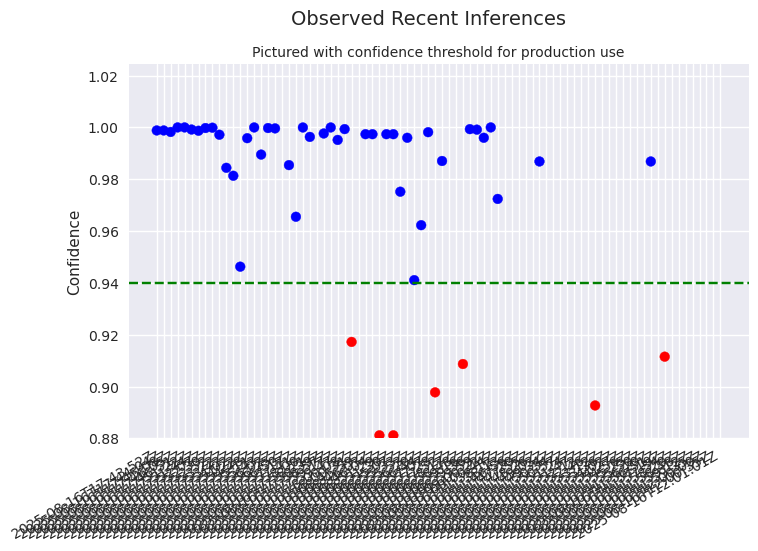

In [114]:
# Populate the data for the x and y axis
x = []
y = []
for obj in json_data:
    inference, timestamp = simple_getter(obj)
    
    y.append(max(inference))
    x.append(timestamp)

# Todo: here is an visualization example, take some time to build another visual that helps monitor the result
# Plot the data
plt.scatter(x, y, c=['r' if k<.94 else 'b' for k in y ])
plt.axhline(y=0.94, color='g', linestyle='--')
plt.ylim(bottom=.88)

# Add labels
plt.ylabel("Confidence")
plt.suptitle("Observed Recent Inferences", size=14)
plt.title("Pictured with confidence threshold for production use", size=10)

# Give it some pizzaz!
plt.style.use("Solarize_Light2")
plt.gcf().autofmt_xdate()

Extracted 85 records for analysis


/tmp/ipykernel_150/536631712.py:194: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


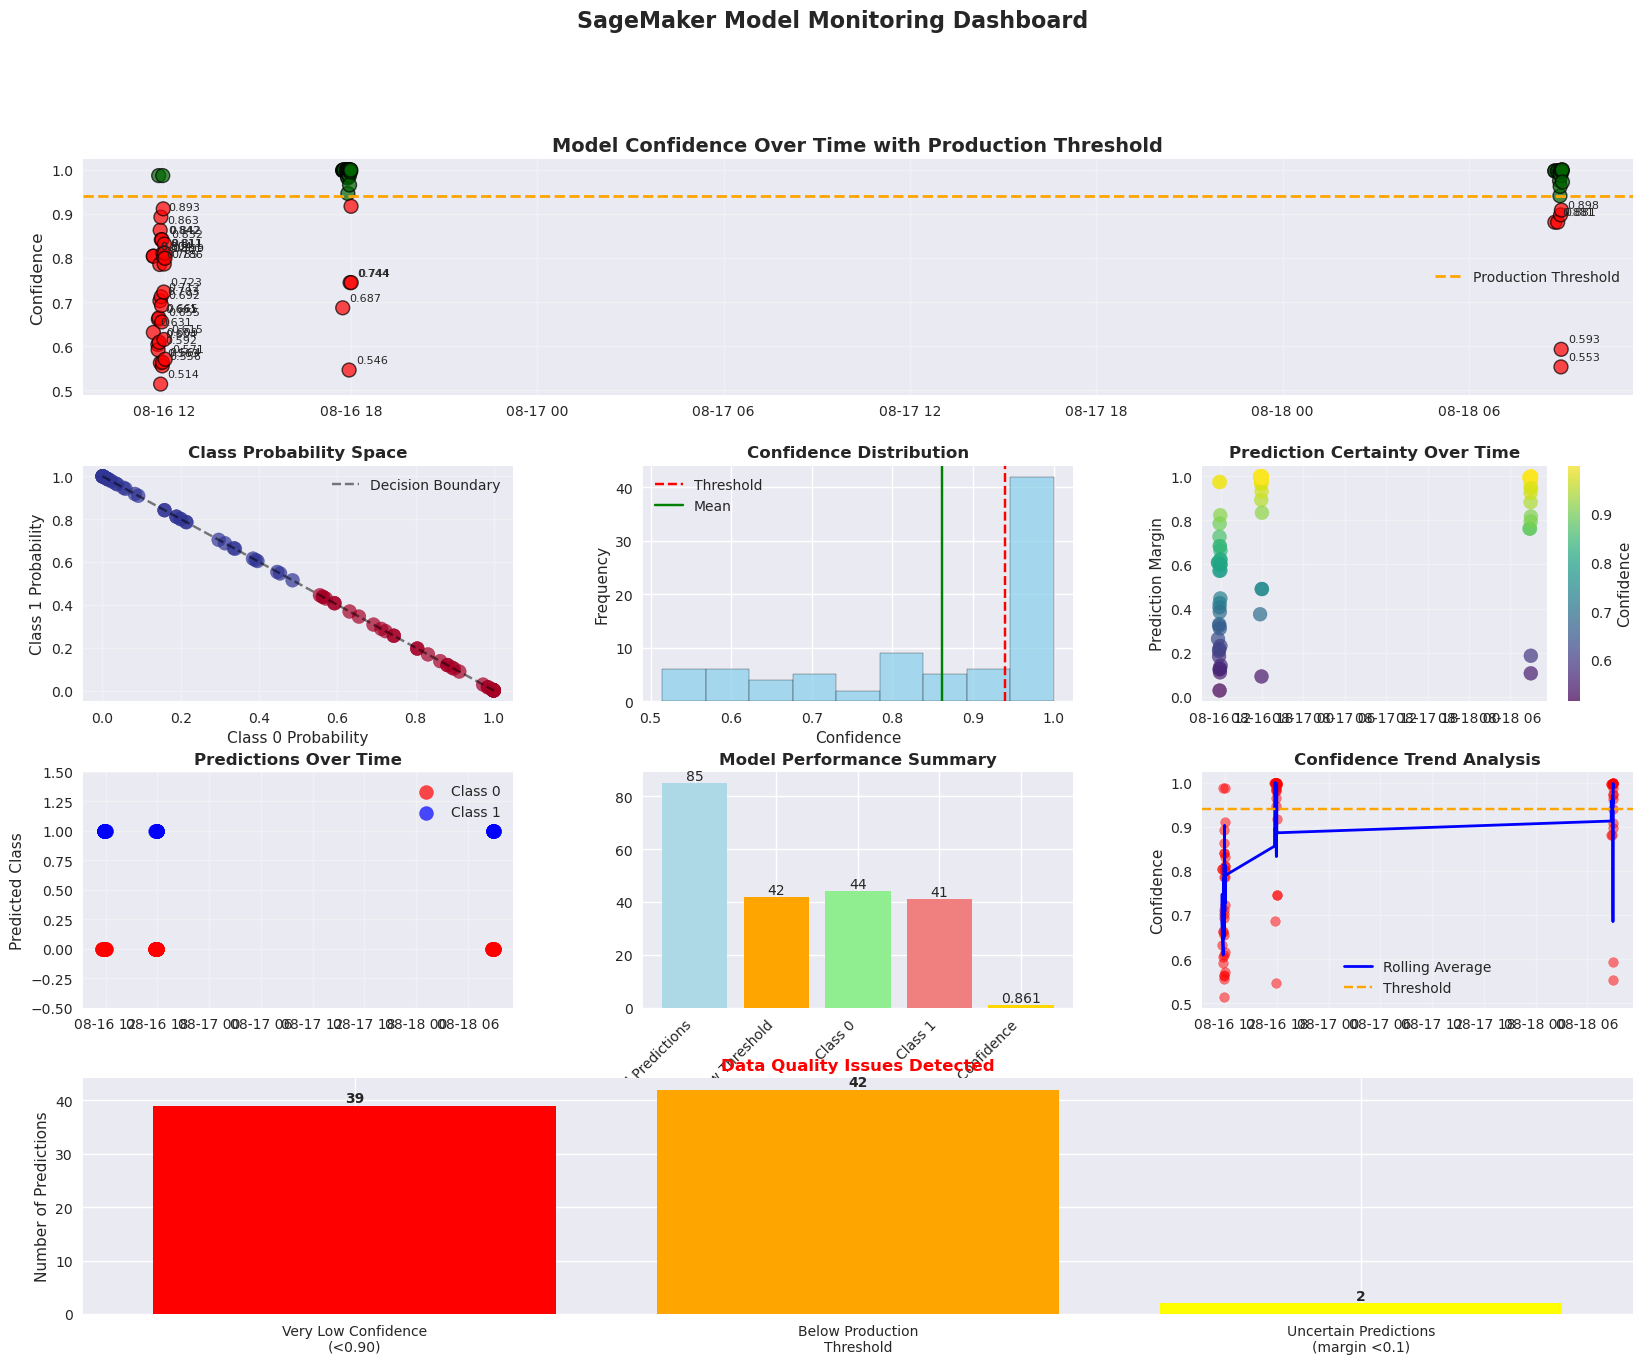


DETAILED MODEL MONITORING REPORT
Analysis Period: 2025-08-16 11:38:12+00:00 to 2025-08-18 09:00:44+00:00
Total Inferences: 85

Confidence Statistics:
  - Mean: 0.8610
  - Std:  0.1584
  - Min:  0.5144
  - Max:  1.0000

Threshold Analysis (0.93):
  - Above threshold: 43 (50.6%)
  - Below threshold: 42 (49.4%)

Class Distribution:
  - Class 0: 44 (51.8%)
  - Class 1: 41 (48.2%)

RECOMMENDATIONS:
⚠️  High confidence variance detected
   - Monitor for inconsistent model behavior


In [123]:
#This code is generated with the help of AI to visualize results better


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime
import json

# Set style for better-looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")



# Extract all data from json_data
def extract_all_data(json_data):
    """Extract predictions, timestamps, and metadata from captured data"""
    data = []
    
    for i, obj in enumerate(json_data):
        try:
            inference, timestamp = simple_getter(obj)
            
            # Extract additional metadata
            inference_id = obj.get('inferenceId', f'inference_{i}')
            endpoint_name = obj.get('endpointName', 'unknown')
            
            data.append({
                'inference_id': inference_id,
                'timestamp': pd.to_datetime(timestamp),
                'class_0_prob': inference[0],
                'class_1_prob': inference[1],
                'max_confidence': max(inference),
                'predicted_class': 0 if inference[0] > inference[1] else 1,
                'prediction_margin': abs(inference[0] - inference[1]),
                'endpoint_name': endpoint_name
            })
        except Exception as e:
            print(f"Error processing record {i}: {e}")
    
    return pd.DataFrame(data)

# Create the dataset
df = extract_all_data(json_data)
print(f"Extracted {len(df)} records for analysis")

# Create a comprehensive dashboard
fig = plt.figure(figsize=(20, 15))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# 1. Enhanced confidence over time with threshold
ax1 = fig.add_subplot(gs[0, :])
colors = ['red' if conf < 0.94 else 'darkgreen' for conf in df['max_confidence']]
scatter = ax1.scatter(df['timestamp'], df['max_confidence'], 
                     c=colors, alpha=0.7, s=100, edgecolors='black', linewidth=1)
ax1.axhline(y=0.94, color='orange', linestyle='--', linewidth=2, label='Production Threshold')
ax1.set_ylabel('Confidence', fontsize=12)
ax1.set_title('Model Confidence Over Time with Production Threshold', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add annotations for low confidence points
for idx, row in df.iterrows():
    if row['max_confidence'] < 0.90:  # Annotate very low confidence
        ax1.annotate(f'{row["max_confidence"]:.3f}', 
                    (row['timestamp'], row['max_confidence']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

# 2. Class probability distribution
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(df['class_0_prob'], df['class_1_prob'], 
           c=df['predicted_class'], cmap='RdYlBu', alpha=0.7, s=100)
ax2.plot([0, 1], [1, 0], 'k--', alpha=0.5, label='Decision Boundary')
ax2.set_xlabel('Class 0 Probability')
ax2.set_ylabel('Class 1 Probability')
ax2.set_title('Class Probability Space', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Confidence distribution histogram
ax3 = fig.add_subplot(gs[1, 1])
bins = np.linspace(df['max_confidence'].min(), df['max_confidence'].max(), 10)
ax3.hist(df['max_confidence'], bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
ax3.axvline(x=0.94, color='red', linestyle='--', label='Threshold')
ax3.axvline(x=df['max_confidence'].mean(), color='green', linestyle='-', label='Mean')
ax3.set_xlabel('Confidence')
ax3.set_ylabel('Frequency')
ax3.set_title('Confidence Distribution', fontweight='bold')
ax3.legend()

# 4. Prediction margin analysis
ax4 = fig.add_subplot(gs[1, 2])
ax4.scatter(df['timestamp'], df['prediction_margin'], 
           c=df['max_confidence'], cmap='viridis', alpha=0.7, s=100)
ax4.set_ylabel('Prediction Margin')
ax4.set_title('Prediction Certainty Over Time', fontweight='bold')
ax4.grid(True, alpha=0.3)
cbar = plt.colorbar(ax4.collections[0], ax=ax4)
cbar.set_label('Confidence')

# 5. Class predictions over time
ax5 = fig.add_subplot(gs[2, 0])
class_colors = ['red', 'blue']
for class_val in [0, 1]:
    class_data = df[df['predicted_class'] == class_val]
    ax5.scatter(class_data['timestamp'], class_data['predicted_class'], 
               c=class_colors[class_val], alpha=0.7, s=100, label=f'Class {class_val}')
ax5.set_ylabel('Predicted Class')
ax5.set_title('Predictions Over Time', fontweight='bold')
ax5.set_ylim(-0.5, 1.5)
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Model performance metrics
ax6 = fig.add_subplot(gs[2, 1])
metrics = {
    'Total Predictions': len(df),
    'Below Threshold': sum(df['max_confidence'] < 0.94),
    'Class 0': sum(df['predicted_class'] == 0),
    'Class 1': sum(df['predicted_class'] == 1),
    'Avg Confidence': df['max_confidence'].mean()
}

bars = ax6.bar(range(len(metrics)), list(metrics.values()), 
               color=['lightblue', 'orange', 'lightgreen', 'lightcoral', 'gold'])
ax6.set_xticks(range(len(metrics)))
ax6.set_xticklabels(list(metrics.keys()), rotation=45, ha='right')
ax6.set_title('Model Performance Summary', fontweight='bold')

# Add value labels on bars
for bar, value in zip(bars, metrics.values()):
    height = bar.get_height()
    if isinstance(value, float):
        ax6.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value:.3f}', ha='center', va='bottom')
    else:
        ax6.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{value}', ha='center', va='bottom')

# 7. Time-based analysis
ax7 = fig.add_subplot(gs[2, 2])
if len(df) > 1:
    df_sorted = df.sort_values('timestamp')
    confidence_trend = df_sorted['max_confidence'].rolling(window=min(3, len(df)), center=True).mean()
    ax7.plot(df_sorted['timestamp'], confidence_trend, 'b-', linewidth=2, label='Rolling Average')
    ax7.scatter(df['timestamp'], df['max_confidence'], alpha=0.5, color='red')
    ax7.axhline(y=0.94, color='orange', linestyle='--', label='Threshold')
ax7.set_ylabel('Confidence')
ax7.set_title('Confidence Trend Analysis', fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

# 8. Data quality assessment
ax8 = fig.add_subplot(gs[3, :])
quality_issues = []
issue_counts = []

# Check for various quality issues
low_conf_count = sum(df['max_confidence'] < 0.90)
if low_conf_count > 0:
    quality_issues.append('Very Low Confidence\n(<0.90)')
    issue_counts.append(low_conf_count)

below_threshold = sum(df['max_confidence'] < 0.93)
if below_threshold > 0:
    quality_issues.append('Below Production\nThreshold')
    issue_counts.append(below_threshold)

uncertain_predictions = sum(df['prediction_margin'] < 0.1)
if uncertain_predictions > 0:
    quality_issues.append('Uncertain Predictions\n(margin <0.1)')
    issue_counts.append(uncertain_predictions)

if quality_issues:
    bars = ax8.bar(quality_issues, issue_counts, color=['red', 'orange', 'yellow'])
    ax8.set_title('Data Quality Issues Detected', fontweight='bold', color='red')
    ax8.set_ylabel('Number of Predictions')
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax8.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')
else:
    ax8.text(0.5, 0.5, 'No Quality Issues Detected!', 
            transform=ax8.transAxes, ha='center', va='center',
            fontsize=16, color='green', fontweight='bold')
    ax8.set_xlim(0, 1)
    ax8.set_ylim(0, 1)

plt.suptitle('SageMaker Model Monitoring Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*60)
print("DETAILED MODEL MONITORING REPORT")
print("="*60)
print(f"Analysis Period: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Total Inferences: {len(df)}")
print(f"\nConfidence Statistics:")
print(f"  - Mean: {df['max_confidence'].mean():.4f}")
print(f"  - Std:  {df['max_confidence'].std():.4f}")
print(f"  - Min:  {df['max_confidence'].min():.4f}")
print(f"  - Max:  {df['max_confidence'].max():.4f}")
print(f"\nThreshold Analysis (0.93):")
print(f"  - Above threshold: {sum(df['max_confidence'] >= 0.93)} ({sum(df['max_confidence'] >= 0.93)/len(df)*100:.1f}%)")
print(f"  - Below threshold: {sum(df['max_confidence'] < 0.93)} ({sum(df['max_confidence'] < 0.93)/len(df)*100:.1f}%)")
print(f"\nClass Distribution:")
print(f"  - Class 0: {sum(df['predicted_class'] == 0)} ({sum(df['predicted_class'] == 0)/len(df)*100:.1f}%)")
print(f"  - Class 1: {sum(df['predicted_class'] == 1)} ({sum(df['predicted_class'] == 1)/len(df)*100:.1f}%)")

# Recommendations
print(f"\nRECOMMENDATIONS:")
if sum(df['max_confidence'] < 0.93) > len(df)*0.60:
    print("⚠️  ATTENTION: All predictions are below production threshold!")
    print("   - Consider investigating model drift")
    print("   - Review recent input data quality")
    print("   - May need model retraining")

if df['max_confidence'].std() > 0.05:
    print("⚠️  High confidence variance detected")
    print("   - Monitor for inconsistent model behavior")

if len(set(df['predicted_class'])) == 1:
    print("⚠️  All predictions are the same class")
    print("   - Check for data bias or model issues")